# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iankitthakur/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
!pip -q install duckdb
import os, json, duckdb, pandas as pd, numpy as np
from google.colab import userdata
RUN_LABEL = "capstone-run-01"

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")
rel = "hf://datasets/FlyRank/internship-warehouse"
con.execute(f"""
CREATE OR REPLACE VIEW march AS
SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/*.parquet')
""")

frame = con.sql("""
SELECT
  client_hash_id, content_hash_id,
  SUM(gsc_impressions)  FILTER (WHERE report_date <= DATE '2026-03-15') AS early_impressions,
  SUM(gsc_clicks)       FILTER (WHERE report_date <= DATE '2026-03-15') AS early_clicks,
  SUM(gsc_clicks) FILTER (WHERE report_date <= DATE '2026-03-15') * 1.0
    / NULLIF(SUM(gsc_impressions) FILTER (WHERE report_date <= DATE '2026-03-15'), 0) AS early_ctr,
  AVG(gsc_avg_position) FILTER (WHERE report_date <= DATE '2026-03-15') AS early_avg_position,
  COUNT(*) FILTER (WHERE report_date <= DATE '2026-03-15' AND gsc_impressions > 0) AS early_active_days,
  SUM(gsc_impressions)  FILTER (WHERE report_date >  DATE '2026-03-15') AS late_impressions
FROM march
WHERE gsc_data_available IS TRUE
  AND hash(content_hash_id) % 50 = 0
GROUP BY 1, 2
""").df()

df = frame[frame["early_impressions"] >= 20].copy()
df["late_impressions"] = df["late_impressions"].fillna(0)
df["label_declining"] = ((df["late_impressions"] / 16) < 0.8 * (df["early_impressions"] / 15)).astype(int)
df = df.sort_values(["client_hash_id", "content_hash_id"]).reset_index(drop=True)
features = ["early_impressions", "early_clicks", "early_ctr", "early_avg_position", "early_active_days"]
X = df[features].fillna(0)
y = df["label_declining"]
groups = df["client_hash_id"]

from sklearn.model_selection import GroupKFold, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

def precision_at_k(y_true, score, k):
    idx = np.argsort(-np.asarray(score), kind="stable")[:k]
    return np.asarray(y_true)[idx].mean()

def peer_baseline(train_idx, apply_idx):
    cut = lambda s: pd.cut(s, [0, 3, 10, 20], labels=["1-3", "4-10", "11-20"]).astype(str)
    tr = df.iloc[train_idx].dropna(subset=["early_avg_position", "early_ctr"])
    tr = tr[tr["early_avg_position"] <= 20]
    sums = tr.groupby(cut(tr["early_avg_position"]))[["early_clicks", "early_impressions"]].sum()
    peer = sums["early_clicks"] / sums["early_impressions"]
    ap = df.iloc[apply_idx]
    score = (cut(ap["early_avg_position"]).map(peer) * ap["early_impressions"] - ap["early_clicks"]).clip(lower=0)
    return score.fillna(0).values

print(RUN_LABEL, df.shape, "declining rate:", round(y.mean(), 3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

capstone-run-01 (2191, 9) declining rate: 0.329


## 1. Question

*The research question and the decision it supports.*

**Question:** which content pages lose search impressions in the second half of a month, and can early-month signals rank them better than a simple, readable rule?

**Decision it supports:** which pages an editor opens first. The output is a ranked review queue for decision-support, not a verdict on any page and not a claim about why a page fell.

**Lane:** Refresh / Content Opportunity Scoring. Every number in this notebook carries the run label capstone-run-01.

In [2]:
print("pages:", len(df), "| declining label rate:", round(y.mean(), 3))
df[["early_impressions", "late_impressions", "label_declining"]].head(5)

pages: 2191 | declining label rate: 0.329


,early_impressions,late_impressions,label_declining
0,283.0,178.0,1
1,53.0,128.0,0
2,74.0,71.0,0
3,1270.0,567.0,1
4,83.0,117.0,0


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release and table:** FlyRank Internship Warehouse (v20260703), table fact_content_daily_performance (one row per report date, client and content item), month 2026-03. All identifiers are hashed; no client names, domains, URLs or queries appear.

**Window:** features from 1–15 March, label from 16–31 March. The decision moment is the end of 15 March.

**Excluded, and why:** rows without Search Console data (missing is not zero); all GA4 columns (only about 4% of rows have them); pages with under 20 early impressions (rates are mostly noise); June 2026, kept sealed as a test month. I used a 2% hash sample of pages to fit in Colab.

In [3]:
display(con.sql("""
SELECT COUNT(*) AS n_rows,
  (SELECT COUNT(*) FROM (SELECT DISTINCT report_date, client_hash_id, content_hash_id FROM march)) AS n_unique_keys
FROM march""").df())
display(con.sql("""
SELECT COUNT(*) AS n_rows, MIN(report_date) AS first_date, MAX(report_date) AS last_date,
  COUNT(DISTINCT client_hash_id) AS n_clients, COUNT(DISTINCT content_hash_id) AS n_pages
FROM march""").df())
display(con.sql("""
SELECT COUNT(*) AS all_rows,
  COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS rows_gsc_available,
  COUNT(*) FILTER (WHERE ga4_data_available IS TRUE) AS rows_ga4_available
FROM march""").df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_rows,n_unique_keys
0,9841378,9841378


,n_rows,first_date,last_date,n_clients,n_pages
0,9841378,2026-03-01,2026-03-31,55,331437


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,all_rows,rows_gsc_available,rows_ga4_available
0,9841378,3611061,413966


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Features (all from 1–15 March, knowable at the decision moment):** early impressions, early clicks, early CTR, early average position, early active days.

**Label:** declining = 1 if impressions per day in 16–31 March are below 80% of the 1–15 March rate. It is a defined rule on observed traffic and a proxy for "worth a human look".

**Baseline:** a readable peer-CTR rule: score = clicks earned below pages at the same position group (1–3, 4–10, 11–20), with peer CTR learned on training folds only.

**Validation:** five folds grouped by client, so no client is in both training and test data. A random 5-fold split is the "before" comparison.

**Leakage checks:** a deliberately leaky column should push AUC toward 1.0; shuffled labels should give about 0.5.

In [4]:
before_splits = list(KFold(n_splits=5, shuffle=True, random_state=0).split(X))
after_splits  = list(GroupKFold(n_splits=5).split(X, y, groups))
for k, (tr, te) in enumerate(before_splits):
    print(f"random fold {k}: test clients also in training = {len(set(groups.iloc[te]) & set(groups.iloc[tr]))} of {groups.iloc[te].nunique()}")
for k, (tr, te) in enumerate(after_splits):
    print(f"grouped fold {k}: clients in both = {len(set(groups.iloc[te]) & set(groups.iloc[tr]))}")

def grouped_auc(cols, target):
    Xc = df[cols].fillna(0)
    p = np.zeros(len(df))
    for tr, te in after_splits:
        m = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=20, random_state=0, n_jobs=-1)
        m.fit(Xc.iloc[tr], target.iloc[tr])
        p[te] = m.predict_proba(Xc.iloc[te])[:, 1]
    return roc_auc_score(target, p)

auc_honest = grouped_auc(features, y)
df["late_vs_early"] = (df["late_impressions"] / 16) / (df["early_impressions"] / 15)   # built from the label window, on purpose
auc_leaky = grouped_auc(features + ["late_vs_early"], y)
df = df.drop(columns=["late_vs_early"])
auc_shuffled = grouped_auc(features, pd.Series(np.random.default_rng(0).permutation(y.values), index=y.index))
print("honest AUC:", round(auc_honest, 3), "| leaky column:", round(auc_leaky, 3), "| shuffled labels:", round(auc_shuffled, 3))

oof_b = np.zeros(len(df))
for tr, te in after_splits:
    oof_b[te] = peer_baseline(tr, te)
s_all = peer_baseline(np.arange(len(df)), np.arange(len(df)))
print("baseline P@50, peer CTR from train folds:", round(precision_at_k(y, oof_b, 50), 3),
      "| from all pages:", round(precision_at_k(y, s_all, 50), 3))

random fold 0: test clients also in training = 24 of 24
random fold 1: test clients also in training = 23 of 24
random fold 2: test clients also in training = 24 of 27
random fold 3: test clients also in training = 23 of 24
random fold 4: test clients also in training = 23 of 25
grouped fold 0: clients in both = 0
grouped fold 1: clients in both = 0
grouped fold 2: clients in both = 0
grouped fold 3: clients in both = 0
grouped fold 4: clients in both = 0
honest AUC: 0.555 | leaky column: 1.0 | shuffled labels: 0.487
baseline P@50, peer CTR from train folds: 0.4 | from all pages: 0.38


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Same pages, same metrics, two splits. Under the grouped split no model clearly beats the readable rule, and the random split flattered the learned models: random forest AUC 0.632 under random folds versus 0.555 grouped, and Precision@50 0.54 versus 0.22. With only 50 pages, Precision@50 moves about 7 points by chance, so the base rate (0.329) is the reference. This is an observed result on one month and about 2,200 pages.

In [5]:
def models():
    return {
        "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
        "Random forest": RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=20, random_state=0, n_jobs=-1),
    }
BASE = "Peer-CTR rule"

def run_split(splits, label):
    oof = {k: np.zeros(len(df)) for k in list(models()) + [BASE]}
    for tr, te in splits:
        for k, m in models().items():
            m.fit(X.iloc[tr], y.iloc[tr])
            oof[k][te] = m.predict_proba(X.iloc[te])[:, 1]
        oof[BASE][te] = peer_baseline(tr, te)
    rows = [{"split": label, "model": k, "AUC": roc_auc_score(y, p),
             "Precision@50": precision_at_k(y, p, 50), "Precision@100": precision_at_k(y, p, 100)}
            for k, p in oof.items()]
    return pd.DataFrame(rows), oof

t_before, _ = run_split(before_splits, "Random")
t_after, oof_after = run_split(after_splits, "Grouped")
print("base rate:", round(y.mean(), 3))
results = pd.concat([t_before, t_after]).round(3)
display(results)

p = pd.Series(oof_after["Logistic regression"], index=df.index)
top50 = df.loc[p.sort_values(ascending=False).head(50).index]
print("logistic regression top 50: declined =", int(top50["label_declining"].sum()),
      "| did not decline =", int((1 - top50["label_declining"]).sum()))

from sklearn.inspection import permutation_importance
tr, te = after_splits[0]
rf = models()["Random forest"].fit(X.iloc[tr], y.iloc[tr])
pi = permutation_importance(rf, X.iloc[te], y.iloc[te], scoring="roc_auc", n_repeats=10, random_state=0)
print(pd.Series(pi.importances_mean, index=features).sort_values(ascending=False).round(3))

base rate: 0.329


,split,model,AUC,Precision@50,Precision@100
0,Random,Logistic regression,0.598,0.44,0.52
1,Random,Random forest,0.632,0.54,0.50
2,Random,Peer-CTR rule,0.570,0.38,0.42
0,Grouped,Logistic regression,0.560,0.38,0.39
1,Grouped,Random forest,0.555,0.22,0.32
2,Grouped,Peer-CTR rule,0.572,0.40,0.43


logistic regression top 50: declined = 19 | did not decline = 31
early_ctr             0.110
early_avg_position    0.050
early_active_days     0.014
early_clicks          0.010
early_impressions     0.003
dtype: float64


## 5. Limitations

*What this work cannot claim.*

- One month (March 2026) and about 2,200 pages from a 2% hash sample; another month could differ.
- Search Console signals only; GA4 covers about 4% of rows, so nothing here speaks to on-site behaviour.
- The split is by client within one month, not across time.
- The label is a proxy and includes regression to the mean: high-impression pages are likelier to fall back.
- Peer CTR is estimated from the same sample it scores.
- No causal claim: nothing here shows that an edit would recover traffic or how Google ranks pages.

In [6]:
print("pages:", len(df), "| clients in the sample:", df["client_hash_id"].nunique(), "| declining share:", round(y.mean(), 3))
print("noise on Precision@50 (about 1 standard error, in points):", round(100 * (y.mean() * (1 - y.mean()) / 50) ** 0.5, 1))

pages: 2191 | clients in the sample: 31 | declining share: 0.329
noise on Precision@50 (about 1 standard error, in points): 6.6


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The playbook is built on the rule, not a model, because no model clearly beat it and an editor can read it. Each page gets a score (clicks below same-position peers), one reason code and one action. A person reviews every queued page before any change; reason codes are hints about where to look, not causes. Do not automate: rewriting titles, merging or pruning pages, promising traffic recovery, judging an author or client by the score, or publishing without review.

In [7]:
d = df.dropna(subset=["early_avg_position", "early_ctr"]).copy()
d["pos_bucket"] = pd.cut(d["early_avg_position"], [0, 3, 10, 20, 1000], labels=["1-3", "4-10", "11-20", "21+"]).astype(str)
sums = d.groupby("pos_bucket")[["early_clicks", "early_impressions"]].sum()
d["peer_ctr"] = d["pos_bucket"].map(sums["early_clicks"] / sums["early_impressions"])
d["score"] = (d["peer_ctr"] * d["early_impressions"] - d["early_clicks"]).clip(lower=0).round(1)
d["archetype"] = np.select(
    [d["early_impressions"] < 100, d["score"] == 0, d["early_avg_position"] <= 10, d["early_avg_position"] <= 20],
    ["Low demand", "At or above peers", "Top-10 under-clicker", "Page-2 under-clicker"],
    default="Deep under-clicker (21+)")
playbook = pd.DataFrame([
    ["Top-10 under-clicker", "CTR_BELOW_PEERS_TOP10", "Rewrite title and meta description"],
    ["Page-2 under-clicker", "CTR_BELOW_PEERS_PAGE2", "Improve content depth and intent match"],
    ["Deep under-clicker (21+)", "CTR_BELOW_PEERS_DEEP", "Review search intent; merge or prune only after a human check"],
    ["Low demand", "LOW_DEMAND", "Monitor only"],
    ["At or above peers", "AT_OR_ABOVE_PEER_CTR", "Protect, no change"],
], columns=["archetype", "reason_code", "action"])
d = d.merge(playbook, on="archetype", how="left")
queue = d[d["archetype"].isin(["Top-10 under-clicker", "Page-2 under-clicker", "Deep under-clicker (21+)"])] \
         .sort_values("score", ascending=False).reset_index(drop=True)
queue.insert(0, "rank", queue.index + 1)

summary = d.groupby("archetype").agg(n=("score", "size"), declining_rate=("label_declining", "mean")).round(3)
q50 = queue.head(50)["label_declining"].mean()
print("pages in queue:", len(queue), "| queue Precision@50:", round(q50, 3), "| base rate:", round(y.mean(), 3))
print("review time per 50 pages at 30 min each (assumption):", 50 * 30 / 60, "hours")
print("expected declining in 50 random picks:", round(50 * y.mean(), 1), "| in queue top 50:", round(50 * q50, 1))
display(summary.join(playbook.set_index("archetype")[["reason_code", "action"]]))

pages in queue: 1032 | queue Precision@50: 0.4 | base rate: 0.329
review time per 50 pages at 30 min each (assumption): 25.0 hours
expected declining in 50 random picks: 16.4 | in queue top 50: 20.0


,n,declining_rate,reason_code,action
archetype,,,,
At or above peers,524,0.242,AT_OR_ABOVE_PEER_CTR,"Protect, no change"
Deep under-clicker (21+),204,0.324,CTR_BELOW_PEERS_DEEP,Review search intent; merge or prune only afte...
Low demand,635,0.335,LOW_DEMAND,Monitor only
Page-2 under-clicker,210,0.348,CTR_BELOW_PEERS_PAGE2,Improve content depth and intent match
Top-10 under-clicker,618,0.390,CTR_BELOW_PEERS_TOP10,Rewrite title and meta description


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Figures and receipts the deployed page uses: Figure 1 (Precision@50 by split), the archetype decline-rate chart (Figure 2) and a metrics file. The ranked queue itself is not committed; this notebook regenerates it.

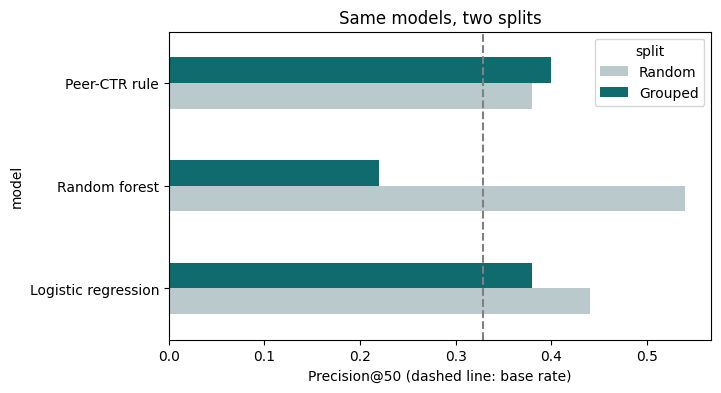

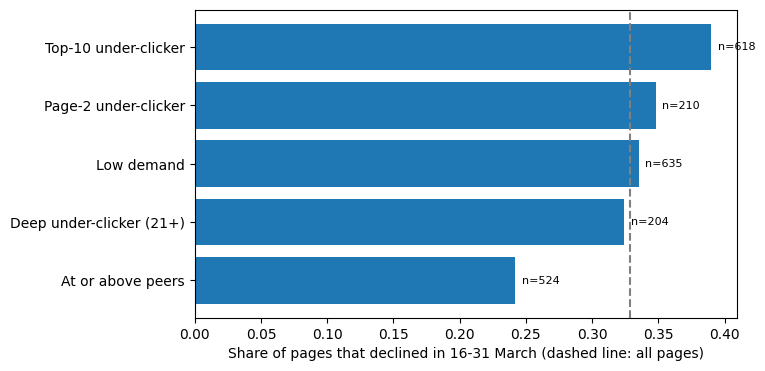

{"honest_auc": 0.555, "leaky_auc": 1.0, "shuffled_auc": 0.487} {'pages_in_queue': 1032, 'precision_at_50': 0.4}


In [8]:
import matplotlib.pyplot as plt
os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

pv = results.pivot(index="model", columns="split", values="Precision@50").loc[["Logistic regression", "Random forest", BASE]]
ax = pv[["Random", "Grouped"]].plot.barh(figsize=(7, 4), color=["#b9c9cc", "#0f6b6e"])
ax.axvline(y.mean(), linestyle="--", color="gray")
ax.set_xlabel("Precision@50 (dashed line: base rate)")
ax.set_title("Same models, two splits")
plt.savefig("work/figures/precision_by_split.png", dpi=150, bbox_inches="tight")
plt.show()

s = summary.sort_values("declining_rate")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(s.index, s["declining_rate"])
ax.axvline(y.mean(), linestyle="--", color="gray")
for i, (r, n) in enumerate(zip(s["declining_rate"], s["n"])):
    ax.text(r + 0.005, i, f"n={n}", va="center", fontsize=8)
ax.set_xlabel("Share of pages that declined in 16-31 March (dashed line: all pages)")
fig.savefig("work/figures/archetype_decline_rate.png", dpi=150, bbox_inches="tight")
plt.show()

metrics = {
    "run_label": RUN_LABEL,
    "window": "features 1-15 March 2026, label 16-31 March 2026",
    "pages": int(len(df)), "base_rate": round(float(y.mean()), 3),
    "results": results.to_dict("records"),
    "leakage": {"honest_auc": round(auc_honest, 3), "leaky_auc": round(auc_leaky, 3), "shuffled_auc": round(auc_shuffled, 3)},
    "queue": {"pages_in_queue": int(len(queue)), "precision_at_50": round(float(q50), 3)},
}
json.dump(metrics, open("work/outputs/capstone_metrics.json", "w"), indent=2)
print(json.dumps(metrics["leakage"]), metrics["queue"])

**5-minute demo outline**
- 0:00–0:30, the question: which pages lose impressions in the second half of a month, and what should an editor open first?
- 0:30–1:15, the data: 9.8 million daily Search Console rows for March 2026 from the FlyRank warehouse (pseudonymized), a 2,191-page sample, features from 1–15 March and a label from 16–31 March.
- 1:15–2:15, method and leakage: a readable peer-CTR rule against logistic regression and a random forest; the deliberate leaky column that pushed AUC to 1.0.
- 2:15–3:30, the finding: show the Figure 1 chart. Learned models looked better under a random split and lost that edge once clients were kept apart; the rule held up.
- 3:30–4:30, the playbook: archetypes, reason codes, human review and the no-go list.
- 4:30–5:00, limits and next step: one month, Search Console only, no causal claim; next, test another month and add content age.

**Social post:** I finished my FlyRank ML Internship capstone: a research paper on 9.8M rows of real search data. The honest finding: a simple, readable rule held up against learned models once I split by client, and a random split made the models look better than they were. Lesson learned: validation design matters more than model complexity. Built on the FlyRank ML Internship dataset (flyrank.ai). Paper: https://iankitthakur.github.io/flyrank-ml-internship/

**Employer-facing summary:** I built and deployed a research paper that ranks content pages for review using real Search Console data (9.8 million rows), with a readable baseline, grouped validation and a leakage audit. I found that no model clearly beat the baseline once validation was honest, and I reported that plainly with careful, non-causal claims. The repo contains every notebook, a ranked action playbook with reason codes and human-review rules, and a live paper.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
